<a href="https://colab.research.google.com/github/ryanaxiom/Applied-ML/blob/main/code/Day14_Carnegie_Model_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student Instructions**: Before you begin, click **File > Save a copy in Drive** so you do not lose your work!

In [ ]:
url = ("https://raw.githubusercontent.com/ryanaxiom/"
       "Applied-ML/main/data/carnegie_data.csv")

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict

carnegie_raw = pd.read_csv(url, encoding="cp1252")
carnegie = carnegie_raw.copy()
carnegie["research"] = carnegie["serd"] + carnegie["nonserd"]
d = carnegie[carnegie["research"].notna()].copy()
d["med_yn"] = (d["medical"] == 1).astype(int)
y = d["research"]
def rmse(a, b): return np.sqrt(np.mean((a - b)**2))
kf = KFold(n_splits=5, shuffle=True, random_state=309)
cands = ["fallenr20", "fallfte20", "ugtenr20", "grtenr20", "totdeg",
         "docrsdeg", "stem_rsd", "socsc_rsd", "hum_rsd", "oth_rsd",
         "facnum", "pdnfrstaff", "rooms", "numcip2", "pctadmitf20",
         "med_yn"]
d.shape, len(cands)

((302, 103), 16)

In [ ]:
print(2**len(cands))
print(f"{2**100:.2e}") # every numeric column

65536
1.27e+30


In [ ]:
def forward(X, y, k):
    chosen = []
    for step in range(k):
        best = None
        for c in X.columns:
            if c in chosen: continue
            m = LinearRegression()
            m.fit(X[chosen + [c]], y)
            e = rmse(y, m.predict(X[chosen + [c]]))
            if best is None or e < best[0]: best = (e, c)
        chosen.append(best[1])
    return chosen
path = forward(d[cands], y, 16)
print(path[:5])

['facnum', 'pdnfrstaff', 'stem_rsd', 'rooms', 'pctadmitf20']


In [ ]:
print(path)

['facnum', 'pdnfrstaff', 'stem_rsd', 'rooms', 'pctadmitf20', 'grtenr20', 'fallfte20', 'socsc_rsd', 'hum_rsd', 'fallenr20', 'totdeg', 'numcip2', 'docrsdeg', 'oth_rsd', 'med_yn', 'ugtenr20']


In [ ]:
val = list(range(17))
print(val)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [ ]:
sum(val)

136

In [ ]:
for k in [1,2,3,5,8,12,16]:
  m = LinearRegression()
  m.fit(d[path[:k]],y)
  print(k,round(rmse(y,m.predict(d[path[:k]]))))

1 241901
2 192293
3 182301
5 168886
8 165514
12 165323
16 165237


In [ ]:
model = LinearRegression()
cv = []
for k in range(1, 17):
    oof = cross_val_predict(model, d[path[:k]], y, cv=kf)
    cv.append(rmse(y, oof))
k_best = int(np.argmin(cv)) + 1
print(k_best, round(cv[k_best - 1]), round(cv[15]))

5 216298 237092


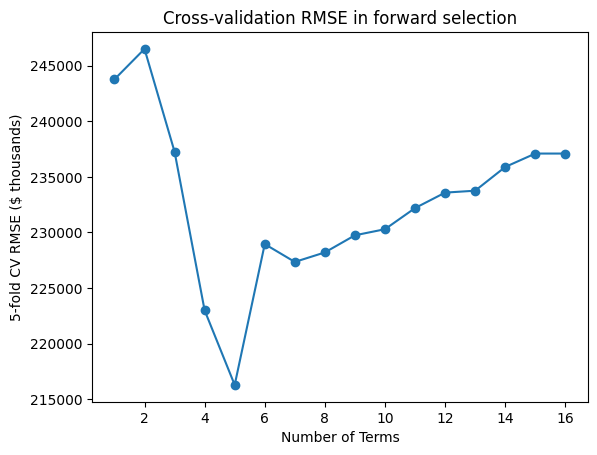

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1,17),cv,marker="o")
plt.title("Cross-validation RMSE in forward selection")
plt.xlabel("Number of Terms")
plt.ylabel("5-fold CV RMSE ($ thousands)")
plt.show()

In [ ]:
vals

['$210,000',
 '$215,000',
 '$220,000',
 '$225,000',
 '$230,000',
 '$235,000',
 '$240,000',
 '$245,000',
 '$250,000']

In [ ]:
def nested(X, y):
    oof = pd.Series(index=y.index, dtype=float)
    for tr, te in kf.split(X):
        Xtr, ytr = X.iloc[tr], y.iloc[tr]
        p = forward(Xtr, ytr, X.shape[1])
        kf_in = KFold(n_splits=5, shuffle=True, random_state=309)
        sc = [rmse(ytr, cross_val_predict(model, Xtr[p[:k]], ytr,
                   cv=kf_in)) for k in range(1, X.shape[1] + 1)]
        k = int(np.argmin(sc)) + 1
        m = LinearRegression()
        m.fit(Xtr[p[:k]], ytr)
        oof.iloc[te] = m.predict(X.iloc[te][p[:k]])
    return rmse(y, oof)

print(round(nested(d[cands], y)))

245336


In [ ]:
rng = np.random.default_rng(309)
noise = pd.DataFrame(rng.normal(size=(len(d), 20)),
                     index=d.index).add_prefix("noise")
both = pd.concat([d[cands], noise], axis=1)
path2 = forward(both, y, 36)
cv2 = [rmse(y, cross_val_predict(model, both[path2[:k]], y, cv=kf))
       for k in range(1, 37)]
k2 = int(np.argmin(cv2)) + 1
print(k2, path2[:k2], round(cv2[k2 - 1]))
print(round(nested(both, y)))

7 ['facnum', 'pdnfrstaff', 'stem_rsd', 'rooms', 'pctadmitf20', 'noise3', 'noise15'] 212661
248345


In [ ]:
from collections import Counter
rng = np.random.default_rng(309)
picks = []
for r in range(200):
    i = rng.choice(len(d), size=len(d), replace=True)
    p = forward(d[cands].iloc[i], y.iloc[i], 3)
    picks.append(tuple(sorted(p)))
print(len(set(picks)))
print(Counter(picks).most_common(5))

17
[(('facnum', 'pdnfrstaff', 'stem_rsd'), 88), (('facnum', 'pctadmitf20', 'pdnfrstaff'), 36), (('facnum', 'grtenr20', 'pdnfrstaff'), 24), (('facnum', 'pdnfrstaff', 'rooms'), 9), (('docrsdeg', 'facnum', 'pdnfrstaff'), 9)]
